# Working with Time Series

## Example: Visualizing Seattle Bicycle Counts

In [54]:
import numpy as np
import pandas as pd
import seaborn
import matplotlib.pyplot as plt

data = pd.read_csv("FremontBridge_2026.csv", index_col="Date", parse_dates=True, date_format="%m/%d/%Y %I:%M:%S %p")
data.head()

,"Fremont Bridge Sidewalks, south of N 34th St Total","Fremont Bridge Sidewalks, south of N 34th St Cyclist West Sidewalk","Fremont Bridge Sidewalks, south of N 34th St Cyclist East Sidewalk"
Date,,,
2026-03-31 23:00:00,22,18.0,4.0
2026-03-31 22:00:00,54,34.0,20.0
2026-03-31 21:00:00,76,47.0,29.0
2026-03-31 20:00:00,67,31.0,36.0
2026-03-31 19:00:00,170,120.0,50.0


In [55]:
data.columns = ['Total', 'West', 'East']
data.head()

,Total,West,East
Date,,,
2026-03-31 23:00:00,22,18.0,4.0
2026-03-31 22:00:00,54,34.0,20.0
2026-03-31 21:00:00,76,47.0,29.0
2026-03-31 20:00:00,67,31.0,36.0
2026-03-31 19:00:00,170,120.0,50.0


In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 118283 entries, 2026-03-31 23:00:00 to 2012-10-02 13:00:00
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Total   118253 non-null  object 
 1   West    118253 non-null  float64
 2   East    118253 non-null  float64
dtypes: float64(2), object(1)
memory usage: 3.6+ MB


In [50]:
data.isnull().sum()

Total    30
West     30
East     30
dtype: int64

In [51]:
data[data.isnull()]

,Total,West,East
Date,,,
2026-03-31 23:00:00,NaN,NaN,NaN
2026-03-31 22:00:00,NaN,NaN,NaN
2026-03-31 21:00:00,NaN,NaN,NaN
2026-03-31 20:00:00,NaN,NaN,NaN
2026-03-31 19:00:00,NaN,NaN,NaN
...,...,...,...
2012-10-02 17:00:00,NaN,NaN,NaN
2012-10-02 16:00:00,NaN,NaN,NaN
2012-10-02 15:00:00,NaN,NaN,NaN


In [52]:
data = data.dropna()
data.isnull().sum()

Total    0
West     0
East     0
dtype: int64

In [45]:
data.describe()

,West,East
count,118253.000000,118253.000000
mean,46.993193,59.815768
std,60.538600,81.251771
min,0.000000,0.000000
25%,6.000000,7.000000
50%,27.000000,31.000000
75%,65.000000,79.000000
max,667.000000,850.000000


In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 118283 entries, 2026-03-31 23:00:00 to 2012-10-02 13:00:00
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Total   118253 non-null  object 
 1   West    118253 non-null  float64
 2   East    118253 non-null  float64
dtypes: float64(2), object(1)
memory usage: 3.6+ MB


In [58]:
data['Total'] = data['Total'].str.replace(",", "")
data['Total'] = data['Total'].astype(float)

In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 118283 entries, 2026-03-31 23:00:00 to 2012-10-02 13:00:00
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Total   118253 non-null  float64
 1   West    118253 non-null  float64
 2   East    118253 non-null  float64
dtypes: float64(3)
memory usage: 3.6 MB


In [60]:
data.describe()

,Total,West,East
count,118253.000000,118253.000000,118253.000000
mean,106.808960,46.993193,59.815768
std,131.108622,60.538600,81.251771
min,0.000000,0.000000,0.000000
25%,14.000000,6.000000,7.000000
50%,61.000000,27.000000,31.000000
75%,147.000000,65.000000,79.000000
max,1097.000000,667.000000,850.000000


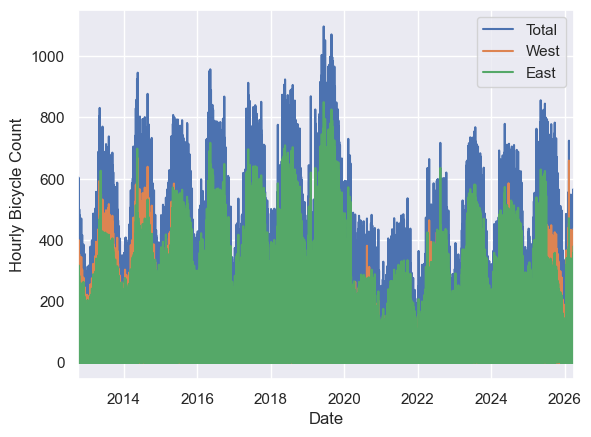

In [64]:
data.plot()
plt.ylabel('Hourly Bicycle Count');

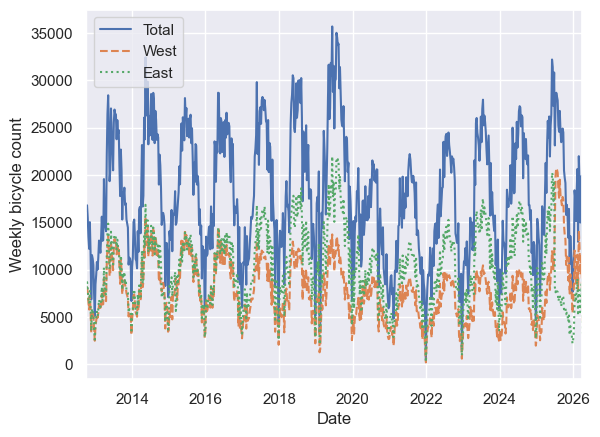

In [91]:
weekly = data.resample('W').sum()
weekly.plot(style=['-', '--', ':'])
plt.ylabel('Weekly bicycle count');

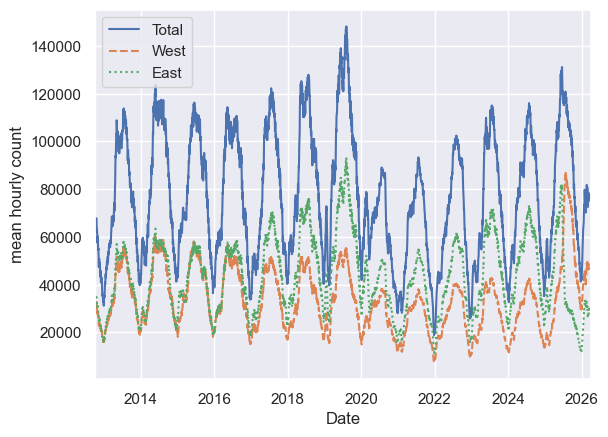

In [92]:
daily = data.resample('D').sum()
daily.rolling(30, center=True).sum().plot(style=['-', '--', ':'])
plt.ylabel('mean hourly count');

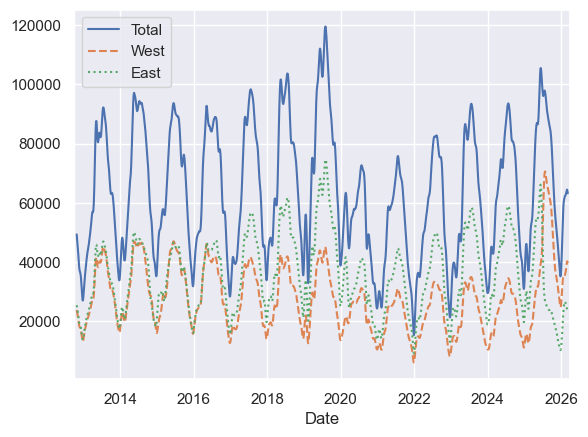

In [93]:
daily.rolling(50, center=True,
              win_type='gaussian').sum(std=10).plot(style=['-', '--', ':']);

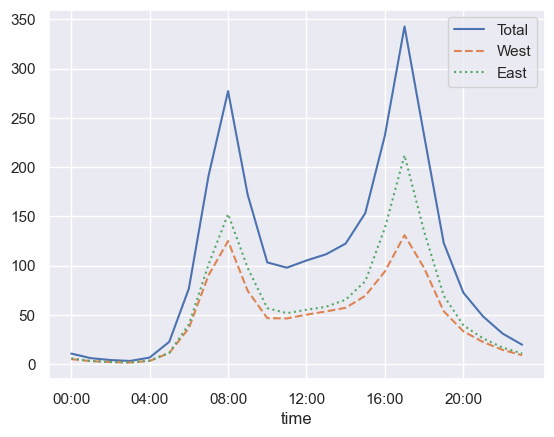

In [94]:
by_time = data.groupby(data.index.time).mean()
hourly_ticks = 4 * 60 * 60 * np.arange(6)
by_time.plot(xticks=hourly_ticks, style=['-', '--', ':']);

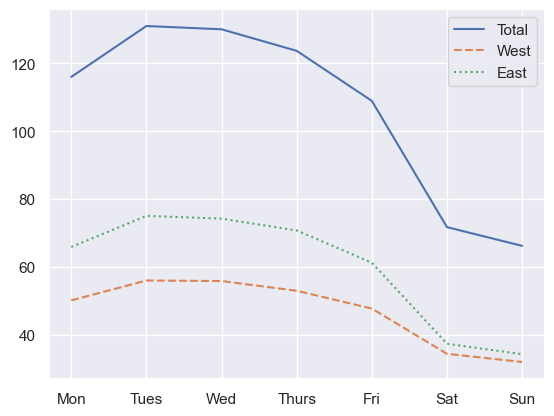

In [96]:
by_weekday = data.groupby(data.index.dayofweek).mean()
by_weekday.index = ['Mon', 'Tues', 'Wed', 'Thurs', 'Fri', 'Sat', 'Sun']
by_weekday.plot(style=['-', '--', ':']);

In [114]:
weekend = np.where(data.index.weekday < 5, 'Weekday', 'Weekend')
by_time = data.groupby([weekend, data.index.time]).mean()

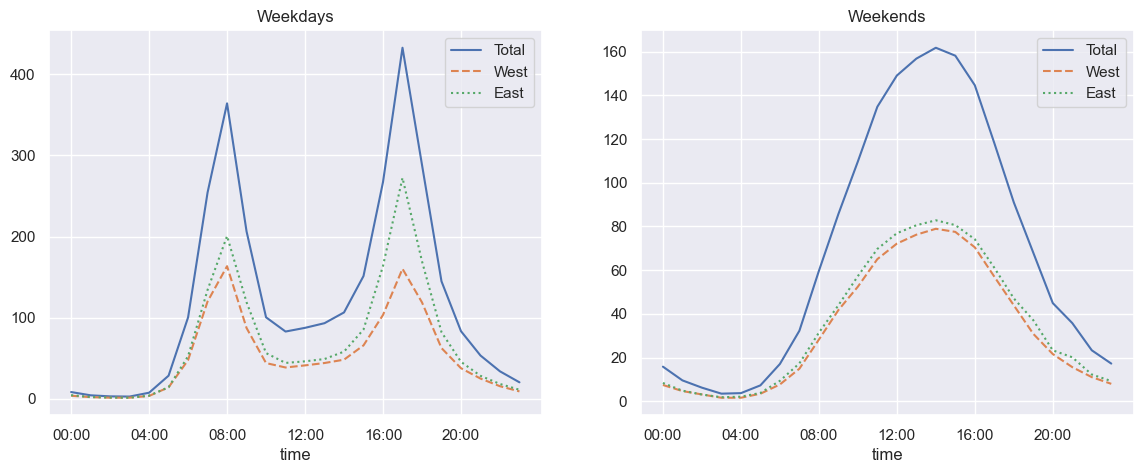

In [116]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
by_time.loc['Weekday'].plot(ax=ax[0], title='Weekdays',
                           xticks=hourly_ticks, style=['-', '--', ':'])
by_time.loc['Weekend'].plot(ax=ax[1], title='Weekends',
                           xticks=hourly_ticks, style=['-', '--', ':']);